# AI模型训练日志分析工具

本实验实现AI模型训练日志的模拟生成、解析和分析功能。


## 一、构造模拟日志文件

生成150条模拟训练日志，包含时间、训练轮次、损失值、准确率四个字段。


In [1]:
import csv
import random
from datetime import datetime, timedelta

random.seed(42)

def generate_training_logs(num_records=150):
    """
    生成模拟训练日志数据
    参数：
        num_records: 日志记录数量，默认150
    返回：
        logs: 日志数据列表
    """
    logs = []
    start_time = datetime(2024, 1, 1, 9, 0, 0)

    loss = 2.5
    accuracy = 0.55

    for epoch in range(1, num_records + 1):
        time_str = (start_time + timedelta(minutes=epoch)).strftime("%Y-%m-%d %H:%M:%S")

        loss_delta = random.uniform(-0.08, 0.02)
        loss = max(0.05, loss + loss_delta)

        acc_delta = random.uniform(-0.005, 0.015)
        accuracy = min(0.99, max(0.5, accuracy + acc_delta))

        logs.append([time_str, epoch, round(loss, 4), round(accuracy, 4)])

    return logs

def save_logs_to_csv(logs, filename='training_logs.csv'):
    """
    将日志数据保存到CSV文件
    参数：
        logs: 日志数据列表
        filename: 输出文件名，默认training_logs.csv
    """
    with open(filename, 'w', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        writer.writerow(['时间', '训练轮次', '损失值', '准确率'])
        writer.writerows(logs)
    print(f"日志文件 {filename} 已生成，共 {len(logs)} 条记录")

logs = generate_training_logs(150)
save_logs_to_csv(logs)

print("\n前10条日志预览：")
print("=" * 60)
print(f"{'时间':<20} {'轮次':<6} {'损失值':<10} {'准确率':<10}")
print("-" * 60)
for log in logs[:10]:
    print(f"{log[0]:<20} {log[1]:<6} {log[2]:<10} {log[3]:<10}")


日志文件 training_logs.csv 已生成，共 150 条记录

前10条日志预览：
时间                   轮次     损失值        准确率       
------------------------------------------------------------
2024-01-01 09:01:00  1      2.4839     0.5455    
2024-01-01 09:02:00  2      2.4314     0.545     
2024-01-01 09:03:00  3      2.4251     0.5535    
2024-01-01 09:04:00  4      2.4343     0.5502    
2024-01-01 09:05:00  5      2.3965     0.5458    
2024-01-01 09:06:00  6      2.3384     0.5509    
2024-01-01 09:07:00  7      2.261      0.5499    
2024-01-01 09:08:00  8      2.246      0.5558    
2024-01-01 09:09:00  9      2.1881     0.5626    
2024-01-01 09:10:00  10     2.189      0.5577    


## 二、读取日志文件并解析

读取CSV文件，将数据存储到字典和列表中。


In [2]:
def parse_log_file(filename='training_logs.csv'):
    """
    解析日志CSV文件
    参数：
        filename: 日志文件名
    返回：
        epoch_dict: 字典，键为训练轮次，值为(损失值, 准确率)元组
        loss_list: 损失值列表
        acc_list: 准确率列表
        epochs: 轮次列表
    """
    epoch_dict = {}
    loss_list = []
    acc_list = []
    epochs = []

    with open(filename, 'r', encoding='utf-8') as f:
        reader = csv.reader(f)
        next(reader)

        for row in reader:
            epoch = int(row[1])
            loss = float(row[2])
            accuracy = float(row[3])

            epoch_dict[epoch] = (loss, accuracy)
            loss_list.append(loss)
            acc_list.append(accuracy)
            epochs.append(epoch)

    return epoch_dict, loss_list, acc_list, epochs

epoch_dict, loss_list, acc_list, epochs = parse_log_file()

print(f"共解析 {len(epochs)} 条日志记录")
print(f"\n字典结构示例（前5个轮次）：")
for epoch in range(1, 6):
    print(f"  轮次 {epoch}: {epoch_dict[epoch]}")

print(f"\n损失值列表前10个: {loss_list[:10]}")
print(f"准确率列表前10个: {acc_list[:10]}")


共解析 150 条日志记录

字典结构示例（前5个轮次）：
  轮次 1: (2.4839, 0.5455)
  轮次 2: (2.4314, 0.545)
  轮次 3: (2.4251, 0.5535)
  轮次 4: (2.4343, 0.5502)
  轮次 5: (2.3965, 0.5458)

损失值列表前10个: [2.4839, 2.4314, 2.4251, 2.4343, 2.3965, 2.3384, 2.261, 2.246, 2.1881, 2.189]
准确率列表前10个: [0.5455, 0.545, 0.5535, 0.5502, 0.5458, 0.5509, 0.5499, 0.5558, 0.5626, 0.5577]


## 三、日志分析

1. 找出损失值最小的训练轮次
2. 统计准确率≥85%的轮次
3. 判断模型是否收敛


In [3]:
def find_min_loss_epoch(epoch_dict):
    """
    顺序穷举查找损失值最小的训练轮次
    参数：
        epoch_dict: 训练轮次字典
    返回：
        min_epoch: 损失值最小的轮次
        min_loss: 最小损失值
        min_acc: 对应准确率
    """
    min_loss = float('inf')
    min_epoch = -1
    min_acc = 0.0

    for epoch, (loss, acc) in epoch_dict.items():
        if loss < min_loss:
            min_loss = loss
            min_epoch = epoch
            min_acc = acc

    return min_epoch, min_loss, min_acc

def count_high_accuracy(acc_list, threshold=0.85):
    """
    统计准确率≥阈值的轮次数量及占比
    参数：
        acc_list: 准确率列表
        threshold: 阈值，默认0.85
    返回：
        count: 满足条件的轮次数量
        ratio: 占比
    """
    count = 0
    for acc in acc_list:
        if acc >= threshold:
            count += 1
    ratio = count / len(acc_list)
    return count, ratio

def check_convergence(loss_list, epochs, window=5, threshold=0.001):
    """
    判断模型是否收敛
    收敛条件：连续window轮损失值变化量≤threshold
    参数：
        loss_list: 损失值列表
        epochs: 轮次列表
        window: 连续轮次窗口，默认5
        threshold: 变化量阈值，默认0.001
    返回：
        converged: 是否收敛
        start_epoch: 收敛起始轮次（若未收敛返回-1）
    """
    for i in range(len(loss_list) - window + 1):
        window_losses = loss_list[i:i+window]
        converged_in_window = True

        for j in range(1, window):
            diff = abs(window_losses[j] - window_losses[j-1])
            if diff > threshold:
                converged_in_window = False
                break

        if converged_in_window:
            return True, epochs[i]

    return False, -1

min_epoch, min_loss, min_acc = find_min_loss_epoch(epoch_dict)
print("=" * 60)
print("分析结果")
print("=" * 60)

print("1. 损失值最小的训练轮次：")
print(f"   轮次: {min_epoch}")
print(f"   损失值: {min_loss}")
print(f"   准确率: {min_acc:.4f}")

high_acc_count, high_acc_ratio = count_high_accuracy(acc_list, 0.85)
print("\n2. 准确率≥85%的训练轮次统计：")
print(f"   数量: {high_acc_count} 轮")
print(f"   占比: {high_acc_ratio * 100:.2f}%")

converged, conv_epoch = check_convergence(loss_list, epochs)
print("\n3. 模型收敛判断：")
if converged:
    print(f"   ✓ 模型已收敛")
    print(f"   收敛起始轮次: 第 {conv_epoch} 轮")
    print(f"   收敛区间损失值变化: {loss_list[conv_epoch-1:conv_epoch+4]}")
else:
    print(f"   ✗ 模型未收敛")
    print(f"   提示: 未出现连续5轮损失值变化量≤0.001的情况")
print("=" * 60)


分析结果
1. 损失值最小的训练轮次：
   轮次: 80
   损失值: 0.05
   准确率: 0.9024

2. 准确率≥85%的训练轮次统计：
   数量: 82 轮
   占比: 54.67%

3. 模型收敛判断：
   ✓ 模型已收敛
   收敛起始轮次: 第 87 轮
   收敛区间损失值变化: [0.05, 0.0507, 0.05, 0.05, 0.05]


## 四、可视化分析结果

绘制损失值和准确率随训练轮次的变化曲线。


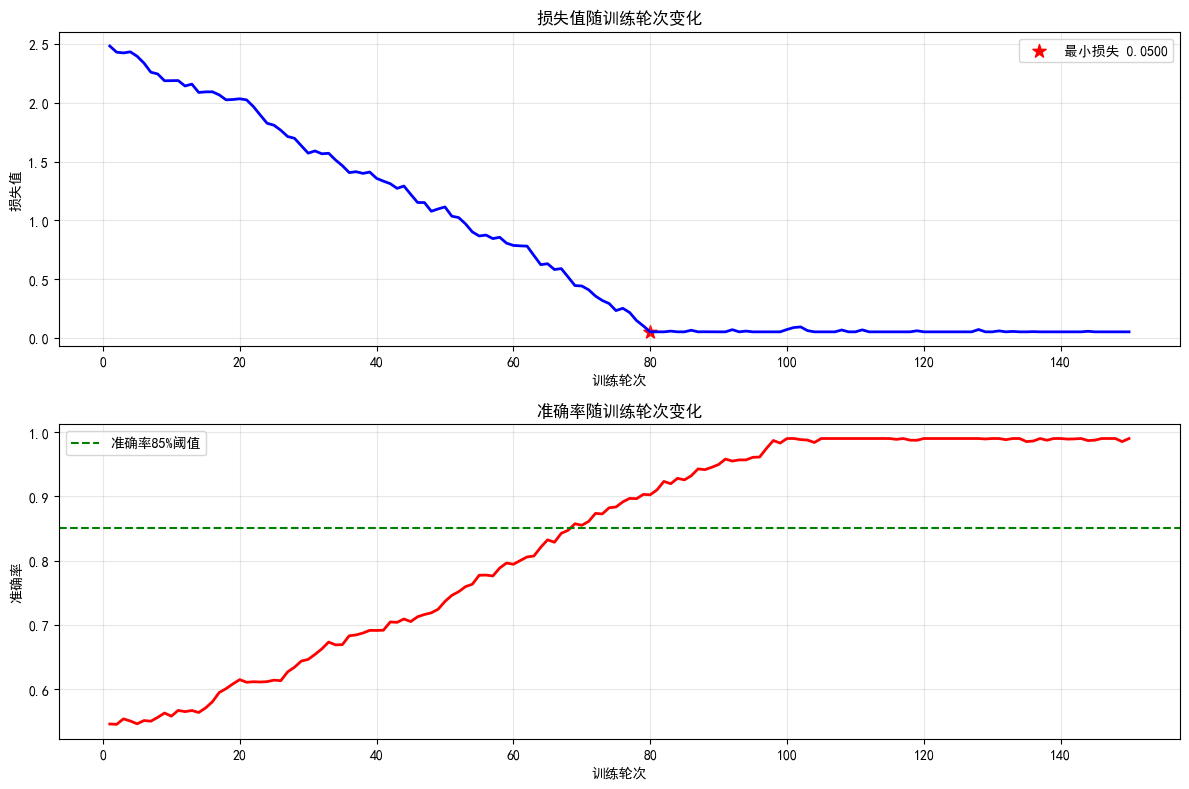

In [4]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plt.plot(epochs, loss_list, 'b-', linewidth=2)
plt.scatter(min_epoch, min_loss, c='red', s=100, marker='*', label=f'最小损失 {min_loss:.4f}')
plt.title('损失值随训练轮次变化')
plt.xlabel('训练轮次')
plt.ylabel('损失值')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 1, 2)
plt.plot(epochs, acc_list, 'r-', linewidth=2)
plt.axhline(y=0.85, color='green', linestyle='--', label='准确率85%阈值')
plt.title('准确率随训练轮次变化')
plt.xlabel('训练轮次')
plt.ylabel('准确率')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
